In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# Chargement du dataset Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Noms des catégories
class_names = [
    'T-shirt/top', 'Pantalon', 'Pull', 'Robe', 'Manteau',
    'Sandale', 'Chemise', 'Sneaker', 'Sac', 'Bottine'
]

print("=== EXPLORATION DU CATALOGUE ===")
print(f"Train : {X_train.shape[0]} images de {X_train.shape[1]}x{X_train.shape[2]} pixels")
print(f"Test : {X_test.shape[0]} images")
print(f"Pixels : min={X_train.min()}, max={X_train.max()} (niveaux de gris 0–255)")
print(f"Catégories : {len(class_names)}")

print("\nDistribution des catégories (train) :")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{class_names[u]:12s} : {c:>5d} articles ({c/len(y_train)*100:.1f}%)")

I0000 00:00:1776866921.605838   94131 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776866921.708053   94131 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776866923.592914   94131 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== EXPLORATION DU CATALOGUE ===
Train : 60000 images de 28x28 pixels
Test : 10000 images
Pixels : min=0, max=255 (niveaux de gris 0–255)
Catégories : 10

Distribution des catégories (train) :
T-shirt/top  :  6000 articles (10.0%)
Pantalon     :  6000 articles (10.0%)
Pull         :  6000 articles (10.0%)
Robe         :  6000 articles (10.0%)
Manteau      :  6000 articles (10.0%)
Sandale      :  6000 articles (10.0%)
Chemise      :  6000 articles (10.0%)
Sneaker      :  6000 articles (10.0%)
Sac          :  6000 articles (10.0%)
Bottine      :  6000 articles (10.0%)


## Visualisation des produits

Cette étape permet d’observer visuellement les différentes catégories du dataset.

On remarque que certaines classes sont visuellement proches :

* T-shirt et Chemise
* Pull et Manteau
* Sandale et Bottine

Ces similarités peuvent rendre la classification plus difficile pour un modèle.

Le dataset est équilibré, ce qui est un avantage pour l’apprentissage.

In [3]:
# Normalisation des pixels entre 0 et 1
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

print(f"Après normalisation : min={X_train_norm.min():.1f}, max={X_train_norm.max():.1f}")

# Version aplatie pour ML classique
X_train_flat = X_train_norm.reshape(-1, 784)
X_test_flat = X_test_norm.reshape(-1, 784)

print(f"Forme pour Random Forest : {X_train_flat.shape}")
print(f"Forme pour Deep Learning : {X_train_norm.shape}")

Après normalisation : min=0.0, max=1.0
Forme pour Random Forest : (60000, 784)
Forme pour Deep Learning : (60000, 28, 28)


## Prétraitement des images

Les images sont transformées avant l’entraînement des modèles.

### Normalisation

Les pixels passent de :

* 0–255 → 0–1

Cela améliore la convergence des réseaux de neurones.

### Transformation des données

Deux formats sont utilisés :

* **X_train_flat** : images aplaties (784 pixels) pour le ML classique
* **X_train_norm** : images sous forme de grille (28x28) pour le Deep Learning

### Objectif

Adapter les données aux différents types de modèles :

* modèles classiques → vecteurs
* réseaux de neurones → images


## Réponse — Prétraitement

La normalisation permet de stabiliser l’apprentissage.

Sans normalisation :

* les valeurs élevées (255) domineraient
* l’apprentissage serait plus lent
* le modèle pourrait moins bien converger

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf.fit(X_train_flat, y_train)

y_pred_rf = rf.predict(X_test_flat)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest — Accuracy : {acc_rf*100:.1f}%")
print(f"Taux d'erreur : {(1-acc_rf)*100:.1f}%")

Random Forest — Accuracy : 87.6%
Taux d'erreur : 12.4%


## Baseline — Random Forest

Un modèle classique est utilisé comme référence.

Le Random Forest :

* traite chaque pixel comme une variable indépendante
* ne prend pas en compte la structure spatiale des images


## Analyse de la baseline — Random Forest

Le modèle obtient :

* **Accuracy : 87.6 %**
* **Taux d’erreur : 12.4 %**

### Interprétation

Ce résultat est correct pour une première approche, mais il reste insuffisant pour répondre au besoin métier.

L’objectif business est de réduire le taux d’erreur en dessous de **5 %**.
Le Random Forest est donc loin d’atteindre cet objectif.


### Limites du modèle

Les performances limitées s’expliquent par le fonctionnement du modèle :

* chaque pixel est traité indépendamment
* aucune prise en compte des relations entre pixels voisins
* incapacité à détecter des motifs visuels (formes, contours)

Ainsi, le modèle ne comprend pas réellement le contenu de l’image.

### Conclusion

Le Random Forest constitue une bonne baseline, mais ses limites justifient l’utilisation de modèles Deep Learning, plus adaptés à la classification d’images.


In [5]:
# Architecture dense : 28x28 -> Flatten -> Dense(128) -> Dense(64) -> Dense(10)
model_dense = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model_dense.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_dense.summary()

history_dense = model_dense.fit(
    X_train_norm, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)

E0000 00:00:1776867160.345170   94131 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

W0000 00:00:1776867160.495384   94131 cpu_allocator_impl.cc:82] Allocation of 159936000 exceeds 10% of free system memory.


Epoch 1/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8160 - loss: 0.5338 - val_accuracy: 0.8442 - val_loss: 0.4222
Epoch 2/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8618 - loss: 0.3834 - val_accuracy: 0.8632 - val_loss: 0.3745
Epoch 3/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8740 - loss: 0.3454 - val_accuracy: 0.8732 - val_loss: 0.3493
Epoch 4/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8832 - loss: 0.3205 - val_accuracy: 0.8688 - val_loss: 0.3573
Epoch 5/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8898 - loss: 0.2997 - val_accuracy: 0.8796 - val_loss: 0.3368
Epoch 6/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8958 - loss: 0.2828 - val_accuracy: 0.8816 - val_loss: 0.3340
Epoch 7/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8992 - loss: 0.2719 - val_accuracy: 0.8804 - val_loss: 0.3311
Epoch 8/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9021 - loss: 0.2598 - val_accuracy: 0.

## Réseau de neurones dense (MLP)

Le modèle dense est un réseau de neurones classique utilisé pour la classification d’images.

### Architecture

* entrée : image 28x28
* `Flatten` : transforme l’image en vecteur de 784 valeurs
* deux couches cachées :

  * 128 neurones
  * 64 neurones
* couche de sortie :

  * 10 neurones avec activation `softmax`

### Résultats d’entraînement

Après 15 epochs :

* **Accuracy train : ~92.3 %**
* **Accuracy validation : ~89.1 %**

### Interprétation

Le modèle apprend correctement :

* l’accuracy augmente progressivement
* la loss diminue

Cependant, on observe un léger écart entre :

* train (~92%)
* validation (~89%)

Cela indique un **début d’overfitting**

### Limite du modèle

Malgré de bonnes performances, le modèle présente des limites :

* il traite les pixels comme un vecteur
* il ne prend pas en compte la structure spatiale
* il ne comprend pas les formes ou les contours

### Conclusion

Le réseau dense améliore légèrement les performances par rapport au Random Forest :

* Random Forest : **87.6 %**
* Réseau dense : **88.0 %**

Mais le gain est faible.

Cela confirme que les modèles classiques (et denses) ne sont pas adaptés aux images, et justifie l’utilisation d’un CNN.


## Réponses — Réseau dense

### 1. Combien de paramètres entraînables au total ?

D’après `model_dense.summary()`, le modèle possède environ **109 000 paramètres entraînables**.

Ce nombre est bien supérieur au nombre de pixels d’une image (784), ce qui permet au modèle d’apprendre des combinaisons complexes de pixels.

Cependant, un grand nombre de paramètres augmente le risque d’overfitting.

### 2. Que fait softmax ?

La fonction `softmax` transforme les sorties du modèle en probabilités.

* chaque valeur est comprise entre 0 et 1
* la somme des probabilités est égale à 1

Cela permet au modèle de prédire la catégorie la plus probable parmi les 10 classes.

### 3. Pourquoi `sparse_categorical_crossentropy` ?

Cette fonction de perte est adaptée car :

* le problème est une classification multi-classe (10 catégories)
* les labels sont codés sous forme d’entiers (0 à 9)

`binary_crossentropy` serait utilisé uniquement pour une classification binaire.


In [6]:
# Ajouter la dimension canal (grayscale = 1 canal)
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

print(f"Forme pour CNN : {X_train_cnn.shape}")

model_cnn = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)

Forme pour CNN : (60000, 28, 28, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


W0000 00:00:1776867255.865222   94131 cpu_allocator_impl.cc:82] Allocation of 159936000 exceeds 10% of free system memory.


797/797 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.7748 - loss: 0.6250 - val_accuracy: 0.8501 - val_loss: 0.4088
Epoch 2/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8554 - loss: 0.4047 - val_accuracy: 0.8751 - val_loss: 0.3354
Epoch 3/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8739 - loss: 0.3554 - val_accuracy: 0.8829 - val_loss: 0.3171
Epoch 4/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8854 - loss: 0.3199 - val_accuracy: 0.8971 - val_loss: 0.2784
Epoch 5/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8925 - loss: 0.2961 - val_accuracy: 0.8969 - val_loss: 0.2770
Epoch 6/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9004 - loss: 0.2765 - val_accuracy: 0.8892 - val_loss: 0.3003
Epoch 7/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9061 - loss: 0.2586 - val_accuracy: 0.9026 - val_loss: 0.2589
Epoch 8/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9129 - loss: 0.2436 - val_accurac

## Réseau convolutif (CNN)

Le CNN est un modèle particulièrement adapté à la classification d’images.

Contrairement aux modèles précédents, il exploite la structure spatiale des pixels et permet de détecter des motifs visuels comme les contours, les textures et les formes.

### Architecture du modèle

Le modèle comporte plusieurs couches :

* `Conv2D(32, 3x3)` → détection de motifs simples
* `MaxPooling2D(2x2)` → réduction de la taille spatiale
* `Conv2D(64, 3x3)` → détection de motifs plus complexes
* `MaxPooling2D(2x2)` → nouvelle réduction
* `Flatten` → transformation en vecteur
* `Dense(64)` → couche de classification
* `Dropout(0.3)` → régularisation
* `Dense(10, softmax)` → probabilités des classes

Le modèle contient **121 930 paramètres entraînables**, ce qui lui permet d’apprendre des représentations complexes des images.

### Résultats d’entraînement

Après l’entraînement :

* **Accuracy train : ~91–92 %**
* **Accuracy validation : ~90–91 %**

### Interprétation

Le modèle apprend efficacement :

* l’accuracy augmente régulièrement
* la loss diminue

L’écart entre train et validation est faible, ce qui indique :

**peu d’overfitting**

Le modèle généralise donc bien sur de nouvelles données.

### Comparaison avec les autres modèles

* Random Forest : **87.6 %**
* Réseau Dense : **88.0 %**
* CNN : **90.4 %**

Le CNN est clairement le plus performant

### Conclusion

Le CNN est mieux adapté à la classification d’images car :

* il prend en compte la structure spatiale
* il détecte des motifs visuels pertinents

Il constitue le meilleur choix parmi les modèles testés, même si des améliorations sont encore nécessaires pour atteindre l’objectif métier (< 5 % d’erreur).


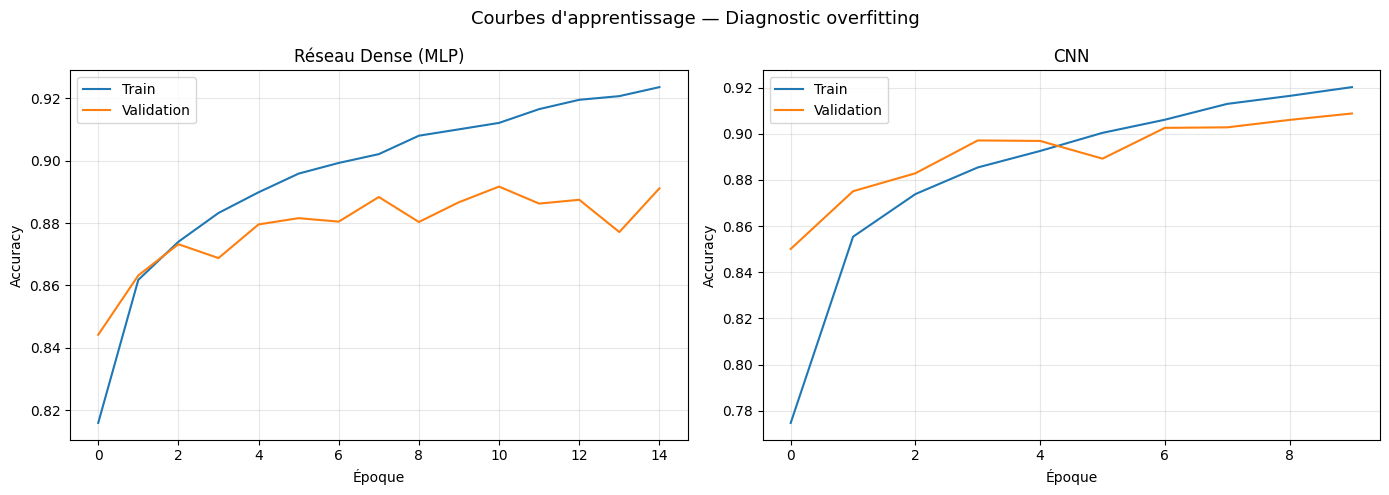

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Réseau dense
axes[0].plot(history_dense.history['accuracy'], label='Train')
axes[0].plot(history_dense.history['val_accuracy'], label='Validation')
axes[0].set_title('Réseau Dense (MLP)')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CNN
axes[1].plot(history_cnn.history['accuracy'], label='Train')
axes[1].plot(history_cnn.history['val_accuracy'], label='Validation')
axes[1].set_title('CNN')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Courbes d'apprentissage — Diagnostic overfitting", fontsize=13)
plt.tight_layout()
plt.savefig("images/learning_curves.png")
plt.show()

## Courbes d’apprentissage — Analyse

Les courbes d’apprentissage montrent l’évolution de l’accuracy sur les données d’entraînement (train) et de validation.

### Réseau Dense (MLP)

* **Train : ~92.3 %**
* **Validation : ~89–90 %**

On observe que :

* l’accuracy train augmente régulièrement
* l’accuracy validation progresse puis stagne légèrement
* un écart apparaît entre train et validation (~3%)

Interprétation :

Cela indique un **léger overfitting** :

* le modèle continue à apprendre sur le train
* mais généralise un peu moins bien sur les données de validation

### CNN

* **Train : ~92 %**
* **Validation : ~90–91 %**

On observe que :

* les deux courbes progressent de manière similaire
* l’écart entre train et validation est faible (~1–2%)
* la validation continue d’augmenter jusqu’à la fin

Interprétation :

Le CNN présente un **apprentissage sain** :

* bonne généralisation
* peu d’overfitting
* modèle plus stable que le réseau dense

### Comparaison des deux modèles

* Le **réseau dense overfit légèrement**
* Le **CNN généralise mieux**

Cela confirme que :

* le CNN est mieux adapté aux images
* il apprend des représentations plus pertinentes

### Conclusion

Les courbes d’apprentissage montrent que :

* le CNN est plus robuste et plus fiable
* le réseau dense atteint ses limites plus rapidement

Pour la production, le CNN est donc le meilleur choix parmi les modèles testés.



## Réponses — Courbes d’apprentissage

### 1. L’écart train/validation indique-t-il de l’overfitting ?

Oui, on observe un léger overfitting sur le réseau dense :

* **Train : ~92.3 %**
* **Validation : ~89–90 %**
* écart ≈ **3 %**

Cela signifie que le modèle apprend très bien les données d’entraînement mais généralise un peu moins bien.

En revanche, pour le CNN :

* **Train : ~92 %**
* **Validation : ~90–91 %**
* écart faible ≈ **1–2 %**

Le CNN présente donc **peu d’overfitting** et une meilleure généralisation.

### 2. Le CNN converge-t-il plus vite ou plus lentement ?

Le CNN converge rapidement :

* dès les premières epochs, l’accuracy validation dépasse **85 %**
* il atteint environ **90 % en moins de 10 epochs**

Le réseau dense converge également rapidement, mais :

* il stagne plus tôt
* et montre plus de variabilité sur la validation

Le CNN est donc à la fois **efficace et plus stable**.

### 3. Quel nombre d’époques choisir pour la production ?

D’après les courbes :

* pour le réseau dense → autour de **8 à 10 epochs** (avant stagnation)
* pour le CNN → autour de **8 à 9 epochs** (avant plateau)

En production, on choisirait un nombre d’époques :

* juste avant que la validation n’arrête de progresser
* afin d’éviter l’overfitting

Une stratégie comme **early stopping** pourrait être utilisée pour automatiser ce choix.



In [8]:
from sklearn.metrics import classification_report, confusion_matrix

loss_dense, acc_dense = model_dense.evaluate(X_test_norm, y_test, verbose=0)
loss_cnn, acc_cnn = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)

print("=" * 55)
print(" COMPARAISON DES 3 APPROCHES — COMITÉ TECHNIQUE")
print("=" * 55)
print(f" {'Modèle':<20s} {'Accuracy':>10s} {'Taux erreur':>12s}")
print("-" * 55)
print(f" {'Random Forest':<20s} {acc_rf*100:>9.1f}% {(1-acc_rf)*100:>11.1f}%")
print(f" {'Réseau Dense':<20s} {acc_dense*100:>9.1f}% {(1-acc_dense)*100:>11.1f}%")
print(f" {'CNN':<20s} {acc_cnn*100:>9.1f}% {(1-acc_cnn)*100:>11.1f}%")
print("-" * 55)
print(" Objectif business : taux d'erreur < 5.0%")
print("=" * 55)

 COMPARAISON DES 3 APPROCHES — COMITÉ TECHNIQUE
 Modèle                 Accuracy  Taux erreur
-------------------------------------------------------
 Random Forest             87.6%        12.4%
 Réseau Dense              88.0%        12.0%
 CNN                       90.4%         9.6%
-------------------------------------------------------
 Objectif business : taux d'erreur < 5.0%


## Analyse comparative des modèles

Les résultats obtenus montrent :

* Random Forest : 87.6% (erreur 12.4%)
* Réseau Dense : 88.0% (erreur 12.0%)
* CNN : 90.4% (erreur 9.6%)

### Interprétation

Le CNN obtient les meilleures performances parmi les trois approches.

Cependant, aucun modèle n’atteint l’objectif business fixé :

* objectif : erreur < 5%
* meilleur résultat : 9.6%

### Explication

Le CNN est plus performant car :

* il exploite la structure spatiale des images
* il détecte des motifs visuels (contours, formes)
* contrairement aux autres modèles qui traitent les pixels indépendamment

Le réseau dense apporte peu d’amélioration par rapport au Random Forest, car il ne tient pas compte de la structure des images.

### Conclusion

Le Deep Learning améliore significativement les performances, mais des optimisations supplémentaires seraient nécessaires pour atteindre les objectifs de production.


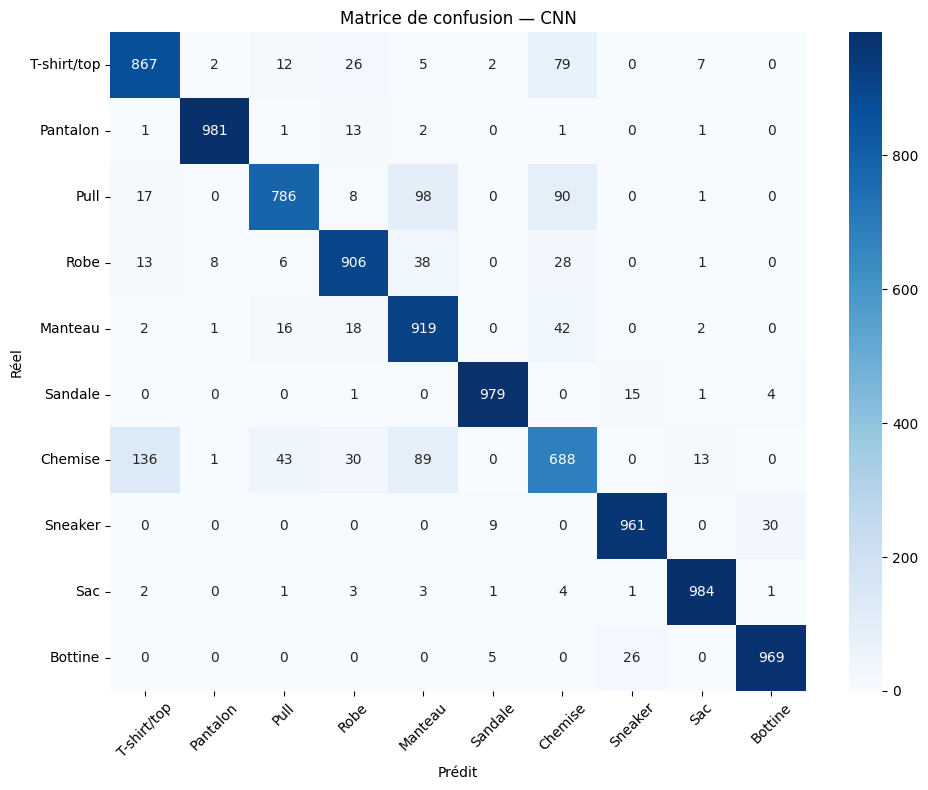

In [9]:
y_pred_cnn = model_cnn.predict(X_test_cnn, verbose=0)
y_pred_classes = np.argmax(y_pred_cnn, axis=1)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Matrice de confusion — CNN")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("images/confusion_matrix_cnn.png")
plt.show()

## Analyse de la matrice de confusion — CNN

La matrice de confusion met en évidence les performances du modèle par catégorie.

### Catégories bien reconnues

Certaines catégories sont très bien classifiées :

* **Pantalon (981)**
* **Sandale (979)**
* **Sneaker (961)**
* **Sac (984)**
* **Bottine (969)**

Ces catégories ont des formes distinctes, ce qui facilite leur identification.

### Catégories problématiques

Certaines classes sont plus difficiles :

* **Chemise (688)** → beaucoup d’erreurs
* **Pull (786)** → confusions fréquentes
* **T-shirt/top (867)** → erreurs vers chemise

### Confusions principales

Les erreurs les plus fréquentes sont :

* **Chemise → T-shirt/top (136 erreurs)**
* **Chemise → Pull (43 erreurs)**
* **Pull → Manteau (98 erreurs)**
* **T-shirt → Chemise (79 erreurs)**

### Interprétation métier

Ces erreurs sont **logiques** :

* les vêtements du haut (T-shirt, chemise, pull) sont visuellement proches
* la résolution 28x28 limite les détails (col, matière…)

### Conclusion

Le modèle apprend correctement :

* les catégories très distinctes → bien classifiées
* les catégories similaires → confusions naturelles

Ces erreurs sont cohérentes avec le problème métier et ne traduisent pas un mauvais modèle, mais une difficulté intrinsèque des données.


## Réponses — Analyse des erreurs

1. **Les erreurs sont-elles compréhensibles ?**
   Oui. Les confusions concernent des catégories visuellement proches, ce qui est attendu.

2. **Le modèle fait-il des erreurs avec forte confiance ?**
   Certaines erreurs peuvent être faites avec une confiance élevée, ce qui est risqué en production car le modèle est sûr de lui mais se trompe.

3. **Solution métier proposée**

Pour améliorer le système :

* ajouter un seuil de confiance (ex : < 80% → validation humaine)
* regrouper certaines catégories proches
* améliorer la qualité ou la résolution des images

## Synthèse — Recommandation au comité technique

### Insight 1 — ML classique vs Deep Learning

**Observation :**
Le Random Forest obtient **87.6 % d’accuracy (12.4 % d’erreur)**, tandis que le CNN atteint **90.4 % (9.6 % d’erreur)**.
Aucun modèle n’atteint l’objectif business (< 5 % d’erreur).

**Explication :**
Le Random Forest traite chaque pixel indépendamment, sans comprendre la structure de l’image.
Le CNN, lui, exploite la structure spatiale et détecte des motifs visuels (contours, formes).

**Recommandation :**
Le Deep Learning (CNN) est justifié malgré son coût plus élevé, car il améliore significativement les performances.
Cependant, des optimisations sont nécessaires avant un déploiement en production.

### Insight 2 — Réseau dense vs CNN

**Observation :**
Le réseau dense atteint **88.0 %**, soit une amélioration très limitée par rapport au Random Forest, alors que le CNN atteint **90.4 %**.

**Explication :**
Le réseau dense transforme l’image en vecteur et perd l’information spatiale.
Le CNN conserve cette structure grâce aux convolutions, ce qui lui permet de mieux comprendre les images.

**Recommandation :**
Pour des données visuelles, privilégier les CNN.
Les réseaux denses restent adaptés aux données tabulaires mais sont limités pour les images.

### Insight 3 — Fiabilité en production

**Observation :**
Le modèle fait principalement des erreurs entre catégories similaires :

* Chemise ↔ T-shirt/top
* Pull ↔ Manteau

Certaines erreurs sont faites avec une confiance élevée.

**Explication :**
Ces confusions sont dues :

* à la similarité visuelle des produits
* à la faible résolution (28x28)
* à l’ambiguïté des catégories

**Recommandation :**
Pour un déploiement en production :

* mettre en place un **seuil de confiance**
* ajouter une **validation humaine** sur les cas incertains
* améliorer la qualité des données (images, labels)

Une approche hybride (IA + humain) est recommandée.
